In [1]:
pip install pyxlsb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd

In [3]:

df = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2020_TO_31-3-2021.xlsx')

In [4]:


df1 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2021_TO_31-3-2022.xlsx', sheet_name='OB_PMR_1-4-2021 to 31-1-2022')



In [5]:
df2 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2021_TO_31-3-2022.xlsx', sheet_name='OB_PMR_1-2-2022 to 31-3-2022')


In [6]:
df3 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2022_TO_31-3-2023.xlsx', sheet_name='1-4-22 to 31-8-22')


In [7]:
df4 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2022_TO_31-3-2023.xlsx', sheet_name='1-9-22 to 31-12-22')


In [8]:
df5 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2022_TO_31-3-2023.xlsx', sheet_name='1-1-23 to 31-3-23')


In [9]:
df6 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2023_TO_31-3-2024.xlsx', sheet_name='1-4-23 to 31-7-23')


In [10]:
df7 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2023_TO_31-3-2024.xlsx', sheet_name='1-8-23 to 31-12-23')


In [11]:
df8 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2023_TO_31-3-2024.xlsx', sheet_name='1-1-24 to 31-3-24')


In [12]:

df9 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2024_TO_31-3-2025.xlsx',sheet_name='01-04-2024 to 31-07-2024')
    #schema_overrides={"TRANSPORTER_CODE": pl.Utf8},  # force text


In [13]:
df10 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2024_TO_31-3-2025.xlsx', sheet_name=' 01-08-1024 to 30-11-2024')


In [14]:
df11 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2024_TO_31-3-2025.xlsx', sheet_name='1-12-24 to 31-1-25')
df12 = pd.read_excel(r'E:\Rahul Verma\document\D drive\PROJECTS\Vscode\50 PLANT PREDICTION\UTCL_1-4-2024_TO_31-3-2025.xlsx', sheet_name='1-2-25 to 31-3-25')



In [15]:
data = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12],
                 ignore_index=True, sort=False)


In [16]:
newdata = pd.concat([df,data],ignore_index=False)

In [17]:
pd.set_option("display.max_rows", None)

In [18]:
newdata = newdata.dropna(subset=['SEQ_LOADER','SEQ_LOADER','MATERIAL_CODE','GrossWeight','GateIn'])

In [19]:
packtype_counts_df = newdata["PACK_TYPE"].value_counts(dropna=False).reset_index(name="COUNT")
packtype_counts_df.columns = ["PACK_TYPE", "COUNT"]
print(packtype_counts_df)


                               PACK_TYPE    COUNT
0                                     HP  5472596
1                                     LC  1304950
2                                  HP|HP   652128
3                                    NaN   568838
4                                    LHS   445564
5                                     LP   254506
6                                    LHC   151012
7                                     LB   113539
8                                    LHW   104691
9                               HP|HP|HP    72001
10                                    LH    66210
11                                 LC|LC    59222
12                                 LP|LP    52359
13                                   HPC    49499
14                                   HPS    40735
15                                   LHU    26170
16                                    PP    15936
17                                  BCMT    15594
18                                 HP|LP    12463


In [20]:
newdata.shape

(9653210, 41)

In [21]:
# Replace NaN values in PACK_TYPE with "Cli"
newdata["PACK_TYPE"] = newdata["PACK_TYPE"].fillna("Cl")


In [22]:
import pandas as pd

def classify_pack(value):

    s = str(value).upper()  # safe for non-strings / NaN -> "NAN"
    # If contains CLI/CLINKER anywhere → Cli
    if "CL" in s or "CLINKER" in s:
        return "Cli"

    # Split tokens and check all are LC → Loose
    tokens = [t.strip() for t in s.split('|') if t.strip()]
    if tokens and all(t == "LC" for t in tokens):
        return "Loose"

    # Otherwise → Bag
    return "Bag"

newdata["PACK"] = newdata["PACK_TYPE"].apply(classify_pack)

In [23]:
newdata['PACK'].unique()

array(['Bag', 'Loose', 'Cli'], dtype=object)

In [24]:
unique_values = newdata["PACK"].unique()
print(unique_values)


['Bag' 'Loose' 'Cli']


In [25]:
value_counts = newdata["PACK"].value_counts()
print(value_counts)


PACK
Bag      7718362
Loose    1365783
Cli       569065
Name: count, dtype: int64


In [26]:
bag_materials = newdata[newdata["PACK"] == "Bag"]["MATERIAL_CODE"].unique().tolist()

for material in bag_materials:
    print(material)


FPPUTHP1200000
FPPUTHP1700000
FIRUTHP1205000
FPPUTHP1760000
FPPUTHP1760000|FPPUTHP1760000
FPPUTHP1200000|FPPUTHP1200000
FPPUTHP1705000
FPPUTHP1705000|FPPUTHP1705000
FPPUTHP1150000
F43UTHP1705000
FPPUTHP1150000|FPPUTHP1150000
FPPUTHP1150000|FPPUTHP1150000|FPPUTHP1150000|FPPUTHP1150000
FPPUTHP1700000|FPPUTHP1700000
F43UTHP1150000
FPPUTHP1150000|FPPUTHP1150000|FPPUTHP1150000
F43UTHP1150000|F43UTHP1150000
FPPUTHP1150000|F43UTHP1150000|FPPUTHP1150000
F43UTHP1705000|F43UTHP1705000
F43UTHP1150000|FPPUTHP1150000
FPPUTHP1150000|F43UTHP1150000
F43UTHP1155000
F43UTHP1150000|FPPUTHP1150000|FPPUTHP1150000
FPPUTHP1760000|FPPUTHP1760000|FPPUTHP1760000
F43UTHP1150000|F43UTHP1150000|F43UTHP1150000
FPPUFLH1150000
F43UTHP1150000|FPPUFLH1150000
FPPUTHP1150000|FPPUFLH1150000
FPPUSLH1700000
FPPUFLH1150000|FPPUTHP1150000
FPPUTHP1150000|F43UTHP1150000|F43UTHP1150000
FPPUSLH1150000
FPPUTHP1150000|FPPUSLH1150000
FPPUSLH1150000|FPPUTHP1150000|FPPUTHP1150000|FPPUTHP1150000
F43UTHP1150000|FPPUTHP1150000|F43UTHP115

In [27]:
bag_materials   = newdata[newdata["PACK"] == "Bag"]["MATERIAL_CODE"].unique().tolist()
loose_materials = newdata[newdata["PACK"] == "Loose"]["MATERIAL_CODE"].unique().tolist()
cli_materials   = newdata[newdata["PACK"] == "Cli"]["MATERIAL_CODE"].unique().tolist()

print("Total Bag Materials:", len(bag_materials))
print("Total Loose Materials:", len(loose_materials))
print("Total Cli Materials:", len(cli_materials))


Total Bag Materials: 3372
Total Loose Materials: 521
Total Cli Materials: 36


In [28]:
bag_materials = newdata[newdata["PACK"] == "Bag"]["MATERIAL_CODE"].unique()
loose_materials = newdata[newdata["PACK"] == "Loose"]["MATERIAL_CODE"].unique()
cli_materials = newdata[newdata["PACK"] == "Cli"]["MATERIAL_CODE"].unique()

print("Bag Materials:", bag_materials)
print("Loose Materials:", loose_materials)
print("Cli Materials:", cli_materials)


Bag Materials: ['FPPUTHP1200000' 'FPPUTHP1700000' 'FIRUTHP1205000' ...
 'FCCUTHP1910000|FCCUTHP1910000|FCCUTHP1910000|FCCUTHP1910000'
 'FCCUTHP1910000|FPPUSHP1910000|FPPUSHP1910000' 'FPPUTHP1993000']
Loose Materials: ['F43UTLC0705000' 'F53UTLC0155000' 'FPPUTLC0205000' 'F43UTLC0155000'
 'F53UTLC0345000' 'F53BSLC0345000' 'F43UTLC0705000|F43UTLC0705000'
 'F53UTLC0343000' 'F53UTLC0153000' 'F53UTLC0343000|F53UTLC0343000'
 'FPPUTLC0765000' 'F43UTLC0153000' 'F53UTLC0155000|F53UTLC0155000'
 'F43UTLC0703000' 'FPPUTLC0763000' 'F43UTLC0155000|F43UTLC0155000'
 'FPPUTLC0203000' 'FPPUTLC0205000|FPPUTLC0205000'
 'FPPUTLC0203000|FPPUTLC0203000' 'FPPUTLC0763000|FPPUTLC0763000'
 'F53UTLC0345000|F53UTLC0345000' 'FPPUTLC0765000|FPPUTLC0765000'
 'F53UTLC0685000' 'F43UTLC0685000' 'F53UTLC0683000' 'FGGUTLC0203000'
 'F43UTLC0685000|F43UTLC0685000' 'F43UTLC0703000|F43UTLC0703000'
 'F53UTLC0685000|F53UTLC0685000' 'FGGUTLC0203000|FGGUTLC0203000'
 'FPPUTLC0705000' 'F53UTLC0684000' 'FPPUTLC0703000' 'FPPUTLC0515000

In [29]:
# Filter only 'Cli' rows
cli_data = newdata[newdata["PACK"] == "Cli"]

# Count each MATERIAL_CODE occurrence
cli_material_counts = cli_data["MATERIAL_CODE"].value_counts()

# Print the counts
print(cli_material_counts)


MATERIAL_CODE
CLINKER                          544592
FPPUTLP1980000                     7261
CLINKERPUR                         6254
FPPUTHP1985000                     3776
CLINKERXGU                         3175
FPPUFLH1980000                     1592
FPPUTHP1980000                      714
N53CEMENT                           689
FPPUTLC0985000                      261
CLINKER6954                         206
FPPKCLH1050000                      203
N53CEMENT6968                       118
CLINKER6951                         101
FPPUTHP1984000                       28
FPCUCLH1240000                       21
FPCUTHP1700000                       17
FPPKLHP1050000|FPPKCLH1050000         9
FPPKCLH1055000                        6
FPPKCLH1050000|FPPKLHP1050000         6
FPPUTLC0605000                        5
F53UTLC0370000                        4
FPPUTHP1950000                        4
F53UTLC0144000                        3
FPPUSLH1370000                        3
F53UTLC0603000            

In [30]:
# Filter only Cli rows
cli_data = newdata[newdata["PACK"] == "Cli"]

# Replace all MATERIAL_CODE values with 'CLINKER'
cli_data["MATERIAL_CODE"] = "CLINKER"

# Now count again to verify
cli_counts = cli_data["MATERIAL_CODE"].value_counts()
print(cli_counts)


MATERIAL_CODE
CLINKER    569065
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_15544\587986480.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cli_data["MATERIAL_CODE"] = "CLINKER"


In [31]:
newdata.head()

,TRIP_ID,VEHICLE_NO,TRANSPORTER_CODE,TRANSPORTER_NAME,SEQ_LOADER,SEQ_PACKER,ACT_LOADER,ACT_PACKER,FIRST_WT,FIRST_WEIGHT_WB_NO,...,TOTAL_TAT,YardIn,GateIn,TareWeight,LoadingIn,LoadingOut,GrossWeight,GateOut,ExitGate,PACK
0,1491304194,CG04JA3454,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,5.03,2,...,360,2020-04-18 12:15:20,2020-04-18 16:36:20,2020-04-18 16:38:09,-,-,2020-04-18 17:56:22,2020-04-18 18:15:40,-,Bag
1,1491304196,CG22AC2282,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,13.12,2,...,332,2020-04-18 13:51:39,2020-04-18 16:57:27,2020-04-18 17:00:15,-,-,2020-04-18 19:20:41,2020-04-18 19:25:00,-,Bag
2,1491304202,CG17GA1151,2201065,CHANDRAPUR ROADWAYS & CO.,Loader5,Packer1,Loader8,Packer2,9.03,2,...,239,2020-04-18 16:16:48,2020-04-18 18:51:02,2020-04-18 18:56:16,2020-04-18 19:08:35,-,2020-04-18 20:08:44,2020-04-18 20:16:46,-,Bag
3,1491304215,CG22AC6267,2201061,Durga road carrier private limited,Loader7,Packer2,Loader8,Packer2,12.8,2,...,171,2020-04-18 18:26:49,2020-04-18 19:20:09,2020-04-18 19:22:59,2020-04-18 20:00:36,-,2020-04-18 21:07:10,2020-04-18 21:18:29,-,Bag
4,1491304213,CG19BG9942,2207515,Mahakal Logistics,Loader7,Packer2,-,-,11.82,2,...,236,2020-04-18 18:01:15,2020-04-18 19:12:51,2020-04-18 19:19:31,-,-,2020-04-18 21:46:14,2020-04-18 21:58:00,-,Bag


In [32]:
print(newdata.head())

      TRIP_ID  VEHICLE_NO TRANSPORTER_CODE  \
0  1491304194  CG04JA3454          2201061   
1  1491304196  CG22AC2282          2201061   
2  1491304202  CG17GA1151          2201065   
3  1491304215  CG22AC6267          2201061   
4  1491304213  CG19BG9942          2207515   

                     TRANSPORTER_NAME SEQ_LOADER SEQ_PACKER ACT_LOADER  \
0  Durga road carrier private limited    Loader5    Packer1          -   
1  Durga road carrier private limited    Loader5    Packer1          -   
2           CHANDRAPUR ROADWAYS & CO.    Loader5    Packer1    Loader8   
3  Durga road carrier private limited    Loader7    Packer2    Loader8   
4                   Mahakal Logistics    Loader7    Packer2          -   

  ACT_PACKER FIRST_WT FIRST_WEIGHT_WB_NO  ... TOTAL_TAT               YardIn  \
0          -     5.03                  2  ...       360  2020-04-18 12:15:20   
1          -    13.12                  2  ...       332  2020-04-18 13:51:39   
2    Packer2     9.03                 

In [33]:
# newdata = clinker_df.copy()

In [34]:
newdata.shape

(9653210, 42)

In [35]:
newdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9653210 entries, 0 to 9313162
Data columns (total 42 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   TRIP_ID              object
 1   VEHICLE_NO           object
 2   TRANSPORTER_CODE     object
 3   TRANSPORTER_NAME     object
 4   SEQ_LOADER           object
 5   SEQ_PACKER           object
 6   ACT_LOADER           object
 7   ACT_PACKER           object
 8   FIRST_WT             object
 9   FIRST_WEIGHT_WB_NO   object
 10  SECOND_WT            object
 11  SECOND_WEIGHT_WB_NO  object
 12  NET_WT               object
 13  PLANT_CODE           object
 14  RSN_NO               object
 15  DI_NO                object
 16  DI_DATETIME          object
 17  READY_QUEUE_TIME     object
 18  DI_QTY               object
 19  MATERIAL_CODE        object
 20  MRP                  object
 21  TOTAL_QTY            object
 22  PACK_TYPE            object
 23  GRDAE                object
 24  BRAND                object
 

In [36]:
pd.set_option('display.max_columns', None) 

In [37]:

# newdata.describe()

In [38]:
newdata['GateOut'] = pd.to_datetime(newdata['GateOut'], errors='coerce')
newdata['GateIn'] = pd.to_datetime(newdata['GateIn'], errors='coerce')

# Now calculate difference in minutes
newdata['GateOut - GateIn'] = (newdata['GateOut'] - newdata['GateIn']).dt.total_seconds() / 60


In [39]:
newdata.head()

,TRIP_ID,VEHICLE_NO,TRANSPORTER_CODE,TRANSPORTER_NAME,SEQ_LOADER,SEQ_PACKER,ACT_LOADER,ACT_PACKER,FIRST_WT,FIRST_WEIGHT_WB_NO,SECOND_WT,SECOND_WEIGHT_WB_NO,NET_WT,PLANT_CODE,RSN_NO,DI_NO,DI_DATETIME,READY_QUEUE_TIME,DI_QTY,MATERIAL_CODE,MRP,TOTAL_QTY,PACK_TYPE,GRDAE,BRAND,PGI_STATUS,PGI_DATE,DESTINATION,APPROVED_TOLERANCE,STATE_NAME,YARD_TAT,PLANT_TAT,TOTAL_TAT,YardIn,GateIn,TareWeight,LoadingIn,LoadingOut,GrossWeight,GateOut,ExitGate,PACK,GateOut - GateIn
0,1491304194,CG04JA3454,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,5.03,2,15.07,2,10.04,GC00,2000469101.0,6920505529,2020-04-18 12:21:45,2020-04-18 16:35:32.347000,10,FPPUTHP1200000,320,10.0,HP,PPC,UT,COMPLETED,2020-04-18 18:08:59,RAIPUR,-,-,261,99,360,2020-04-18 12:15:20,2020-04-18 16:36:20,2020-04-18 16:38:09,-,-,2020-04-18 17:56:22,2020-04-18 18:15:40,-,Bag,99.333333
1,1491304196,CG22AC2282,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,13.12,2,43.23,1,30.11,GC00,2000469103.0,6920505531,2020-04-18 15:51:58,2020-04-18 16:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 19:23:36,RAIPUR,-,-,185,147,332,2020-04-18 13:51:39,2020-04-18 16:57:27,2020-04-18 17:00:15,-,-,2020-04-18 19:20:41,2020-04-18 19:25:00,-,Bag,147.550000
2,1491304202,CG17GA1151,2201065,CHANDRAPUR ROADWAYS & CO.,Loader5,Packer1,Loader8,Packer2,9.03,2,29.09,1,20.06,GC00,2000469106.0,6920505534,2020-04-18 18:38:37,2020-04-18 18:44:00,20,FPPUTHP1200000,320,20.0,HP,PPC,UT,COMPLETED,2020-04-18 20:13:55,RAIPUR-II,-,-,154,85,239,2020-04-18 16:16:48,2020-04-18 18:51:02,2020-04-18 18:56:16,2020-04-18 19:08:35,-,2020-04-18 20:08:44,2020-04-18 20:16:46,-,Bag,85.733333
3,1491304215,CG22AC6267,2201061,Durga road carrier private limited,Loader7,Packer2,Loader8,Packer2,12.8,2,42.89,1,30.09,GC00,2000469104.0,6920505532,2020-04-18 18:49:20,2020-04-18 18:51:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:11:48,RAIPUR,-,-,53,118,171,2020-04-18 18:26:49,2020-04-18 19:20:09,2020-04-18 19:22:59,2020-04-18 20:00:36,-,2020-04-18 21:07:10,2020-04-18 21:18:29,-,Bag,118.333333
4,1491304213,CG19BG9942,2207515,Mahakal Logistics,Loader7,Packer2,-,-,11.82,2,41.89,2,30.07,GC00,2000469109.0,6920505537,2020-04-18 18:29:32,2020-04-18 18:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:48:32,RAIPUR-II,-,-,71,165,236,2020-04-18 18:01:15,2020-04-18 19:12:51,2020-04-18 19:19:31,-,-,2020-04-18 21:46:14,2020-04-18 21:58:00,-,Bag,165.150000


In [40]:
newdata = newdata[newdata['GateOut - GateIn'] >= 0]

In [41]:
# Average time in minutes
avg_minutes = newdata['GateOut - GateIn'].mean()

print(f"Average GateOut - GateIn time: {avg_minutes:.2f} minutes")

Average GateOut - GateIn time: 203.65 minutes


In [42]:
# Check the minimum and maximum values of the new column
min_value = newdata['GateOut - GateIn'].min()
max_value = newdata['GateOut - GateIn'].max()
print(f"Minimum value {min_value} minutes")
print(f"Maximum value {max_value} minutes")

Minimum value 0.0 minutes
Maximum value 403460.2166666667 minutes


In [43]:
import pandas as pd
Q1 = newdata['GateOut - GateIn'].quantile(0.25)
Q3 = newdata['GateOut - GateIn'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)  # ensure no negative bound
upper_bound = Q3 + 1.5 * IQR

outliers = newdata[(newdata['GateOut - GateIn'] < lower_bound) | 
                   (newdata['GateOut - GateIn'] > upper_bound)]

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Outliers count: {outliers.shape[0]}")


Lower bound: 0, Upper bound: 459.2583333333334
Outliers count: 667851


In [44]:
import pandas as pd

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90K']

newdata['TOTAL_QTY_Group'] = pd.cut(newdata['TOTAL_QTY'], bins=bins, labels=labels)


In [45]:
newdata.shape

(9653206, 44)

In [46]:
clean_data = newdata.copy()

In [47]:
clean_data.shape

(9653206, 44)

In [48]:
import pandas as pd
import numpy as np

# 2) Outlier detection in GateOut - GateIn for each bucket
outlier_summary = []

for group, data in newdata.groupby('TOTAL_QTY_Group'):
    if data['GateOut - GateIn'].empty:
        outlier_summary.append((group, 0, None, None))
        continue

    Q1 = data['GateOut - GateIn'].quantile(0.25)
    Q3 = data['GateOut - GateIn'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data['GateOut - GateIn'] < lower_bound) | (data['GateOut - GateIn'] > upper_bound)]
    
    outlier_summary.append((group, len(outliers), lower_bound, upper_bound))

print("Outlier Summary (GateOut - GateIn per TOTAL_QTY bucket):")
for group, count, lb, ub in outlier_summary:
    lb_str = f"{lb:.2f}" if lb is not None else "NA"
    ub_str = f"{ub:.2f}" if ub is not None else "NA"
    print(f"Bucket {group}: {count} outliers | Lower={lb_str} | Upper={ub_str}")



C:\Users\User\AppData\Local\Temp\ipykernel_15544\3771262984.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in newdata.groupby('TOTAL_QTY_Group'):


Outlier Summary (GateOut - GateIn per TOTAL_QTY bucket):
Bucket 0-10: 54551 outliers | Lower=-43.63 | Upper=203.03
Bucket 10-20: 139946 outliers | Lower=-66.98 | Upper=335.95
Bucket 20-30: 195828 outliers | Lower=-110.02 | Upper=470.25
Bucket 30-40: 164181 outliers | Lower=-109.39 | Upper=497.47
Bucket 40-50: 92046 outliers | Lower=-190.02 | Upper=623.98
Bucket 50-60: 4024 outliers | Lower=-154.95 | Upper=658.08
Bucket 60-70: 2425 outliers | Lower=-218.55 | Upper=778.12
Bucket 70-80: 41 outliers | Lower=-172.07 | Upper=749.30
Bucket 80-90: 16 outliers | Lower=-257.29 | Upper=952.15
Bucket 90K: 0 outliers | Lower=-64.33 | Upper=1035.80


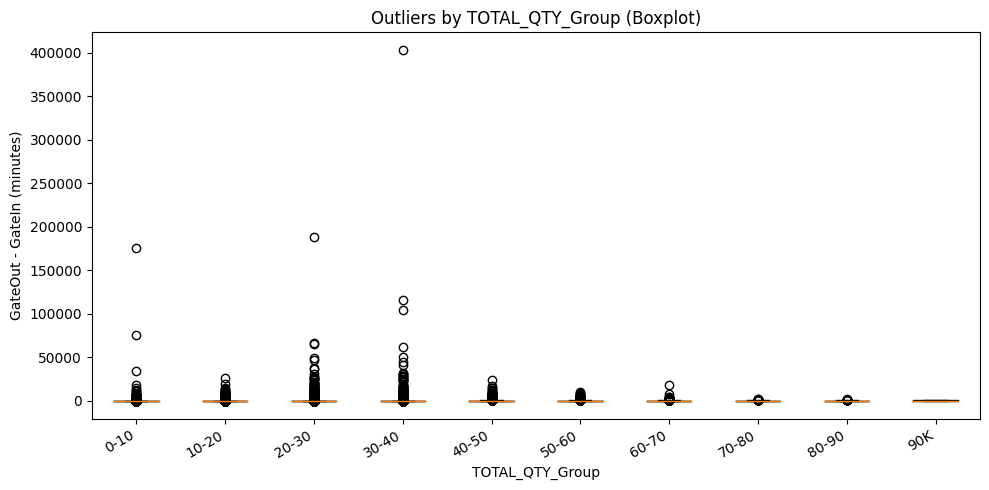

In [49]:
import matplotlib.pyplot as plt

# Prepare data for boxplot (order buckets nicely)
bucket_order = sorted(newdata['TOTAL_QTY_Group'].dropna().unique())
box_data = [newdata.loc[newdata['TOTAL_QTY_Group']==b, 'GateOut - GateIn'].dropna().values
            for b in bucket_order]

plt.figure(figsize=(10, 5))
plt.boxplot(box_data, labels=[str(b) for b in bucket_order], showfliers=True)
plt.xlabel("TOTAL_QTY_Group")
plt.ylabel("GateOut - GateIn (minutes)")
plt.title("Outliers by TOTAL_QTY_Group (Boxplot)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [50]:
import pandas as pd
import numpy as np

# Count total outliers across all buckets (no column added)
s = pd.to_numeric(newdata['GateOut - GateIn'], errors='coerce')

def count_outliers(x):
    x = x.dropna()
    if x.empty: 
        return 0
    q1 = x.quantile(0.25); q3 = x.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((x < lb) | (x > ub)).sum()

total_outliers = int(
    s.groupby(newdata['TOTAL_QTY_Group'], dropna=False).apply(count_outliers).sum()
)

print("Total outliers:", total_outliers)


C:\Users\User\AppData\Local\Temp\ipykernel_15544\1739393837.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s.groupby(newdata['TOTAL_QTY_Group'], dropna=False).apply(count_outliers).sum()


Total outliers: 653064


In [51]:
bounds = {}

def get_outliers(group):
    Q1 = group['GateOut - GateIn'].quantile(0.25)
    Q3 = group['GateOut - GateIn'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower < 0:
        positive_vals = group[group['GateOut - GateIn'] > 0]['GateOut - GateIn']
        if not positive_vals.empty:
           lower = positive_vals.min()
        else:
            lower = 0

    bounds[group.name] = {
        "Lower": lower,
        "Upper": upper,
        "Min": group['GateOut - GateIn'].min(),
        "Max": group['GateOut - GateIn'].max()
    }
    return group[(group['GateOut - GateIn'] < lower) | (group['GateOut - GateIn'] > upper)]

In [52]:
outliers = newdata.groupby('TOTAL_QTY_Group', group_keys=False).apply(get_outliers)

C:\Users\User\AppData\Local\Temp\ipykernel_15544\3434131338.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outliers = newdata.groupby('TOTAL_QTY_Group', group_keys=False).apply(get_outliers)


In [53]:
bounds_df = pd.DataFrame(bounds).T.reset_index()
bounds_df.rename(columns={'index': 'TOTAL_QTY_Group'}, inplace=True)
print(bounds_df)


  TOTAL_QTY_Group       Lower        Upper         Min            Max
0            0-10    5.250000   203.033333    5.250000  175499.866667
1           10-20    4.350000   335.950000    4.350000   26231.083333
2           20-30    1.166667   470.250000    0.000000  188624.600000
3           30-40    4.450000   497.475000    4.450000  403460.216667
4           40-50    3.083333   623.983333    3.083333   24498.516667
5           50-60   16.983333   658.083333   16.983333   10445.133333
6           60-70    9.983333   778.116667    9.983333   18462.683333
7           70-80   30.900000   749.295833   30.900000    2520.250000
8           80-90   47.533333   952.145833   47.533333    1921.983333
9             90K  258.500000  1035.800000  258.500000     808.566667


In [54]:
grp = 'TOTAL_QTY_Group'
col = 'GateOut - GateIn'
s = pd.to_numeric(newdata[col], errors='coerce')

def mark_outlier(x: pd.Series) -> pd.Series:
    x = x.dropna()
    if x.empty:
        return pd.Series([False] * len(x), index=x.index)
    q1 = x.quantile(0.25); q3 = x.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (x < lb) | (x > ub)

# Outlier mask WITHOUT adding a column
mask_outlier = (
    s.groupby(newdata[grp], dropna=False)
     .transform(mark_outlier)
     .fillna(False)
     .astype(bool)
)
g = newdata[grp]
# trips per bucket
trip_summary = (
    g.groupby(g, dropna=False)
     .size()
     .reset_index(name='trips')
    .rename(columns={grp: grp})
)

# outliers per bucket (sum of True)
out_by_group = (
    pd.Series(mask_outlier, index=newdata.index)
      .groupby(g, dropna=False)
      .sum()
      .astype('int64')
      .reset_index(name='outliers')
)

# merge + metrics
summary = trip_summary.merge(out_by_group, on=grp, how='left').fillna({'outliers': 0})
summary['outliers'] = summary['outliers'].astype('int64')
summary['inliers']  = summary['trips'] - summary['outliers']

total_trips = summary['trips'].sum()
summary['trip_pct']    = (summary['trips']    / total_trips * 100).round(0)   # as in pic (whole %)
summary['outlier_pct'] = (summary['outliers'] / summary['trips'].replace(0, np.nan) * 100).round(1)
summary['outlier_pct'] = summary['outlier_pct'].fillna(0)

# keep your bucket order (if you have bounds_df)
order = list(bounds_df['TOTAL_QTY_Group'])
summary[grp] = pd.Categorical(summary[grp], categories=order, ordered=True)
summary = summary.sort_values(grp).reset_index(drop=True)

print(summary[[grp, 'trips', 'trip_pct', 'outliers', 'outlier_pct', 'inliers']])


C:\Users\User\AppData\Local\Temp\ipykernel_15544\832550340.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s.groupby(newdata[grp], dropna=False)


C:\Users\User\AppData\Local\Temp\ipykernel_15544\832550340.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(g, dropna=False)
C:\Users\User\AppData\Local\Temp\ipykernel_15544\832550340.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(g, dropna=False)


   TOTAL_QTY_Group    trips  trip_pct  outliers  outlier_pct  inliers
0             0-10   879160       9.0     54551          6.2   824609
1            10-20  2051385      21.0    139946          6.8  1911439
2            20-30  2956131      31.0    195828          6.6  2760303
3            30-40  2366767      25.0    164181          6.9  2202586
4            40-50  1312731      14.0     92046          7.0  1220685
5            50-60    55102       1.0      4024          7.3    51078
6            60-70    30973       0.0      2425          7.8    28548
7            70-80      303       0.0        41         13.5      262
8            80-90      616       0.0        16          2.6      600
9              90K        3       0.0         0          0.0        3
10             NaN       35       0.0         6         17.1       29


In [55]:

def mark_outlier(x):
    q1 = x.quantile(0.25); q3 = x.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (x < lb) | (x > ub)

# compute mask WITHOUT assigning to a column
mask_outlier = (
    s.groupby(newdata[grp], dropna=False)
     .transform(mark_outlier)
     .fillna(False)
     .astype(bool)
)
# filter using the mask (no 'Outlier' column created)
Clean_data = newdata.loc[~mask_outlier].reset_index(drop=True)

print(f"Original rows: {len(newdata)}")
print(f"Outliers removed: {int(mask_outlier.sum())}")
print(f"After removing outliers: {len(Clean_data)}")

C:\Users\User\AppData\Local\Temp\ipykernel_15544\2943725454.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s.groupby(newdata[grp], dropna=False)


Original rows: 9653206
Outliers removed: 653064
After removing outliers: 9000142


In [56]:
Clean_data = newdata.copy()

ERROR! Session/line number was not unique in database. History logging moved to new session 451


In [57]:
Clean_data.shape

(9653206, 44)

In [58]:
clean_data.head()

,TRIP_ID,VEHICLE_NO,TRANSPORTER_CODE,TRANSPORTER_NAME,SEQ_LOADER,SEQ_PACKER,ACT_LOADER,ACT_PACKER,FIRST_WT,FIRST_WEIGHT_WB_NO,SECOND_WT,SECOND_WEIGHT_WB_NO,NET_WT,PLANT_CODE,RSN_NO,DI_NO,DI_DATETIME,READY_QUEUE_TIME,DI_QTY,MATERIAL_CODE,MRP,TOTAL_QTY,PACK_TYPE,GRDAE,BRAND,PGI_STATUS,PGI_DATE,DESTINATION,APPROVED_TOLERANCE,STATE_NAME,YARD_TAT,PLANT_TAT,TOTAL_TAT,YardIn,GateIn,TareWeight,LoadingIn,LoadingOut,GrossWeight,GateOut,ExitGate,PACK,GateOut - GateIn,TOTAL_QTY_Group
0,1491304194,CG04JA3454,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,5.03,2,15.07,2,10.04,GC00,2000469101.0,6920505529,2020-04-18 12:21:45,2020-04-18 16:35:32.347000,10,FPPUTHP1200000,320,10.0,HP,PPC,UT,COMPLETED,2020-04-18 18:08:59,RAIPUR,-,-,261,99,360,2020-04-18 12:15:20,2020-04-18 16:36:20,2020-04-18 16:38:09,-,-,2020-04-18 17:56:22,2020-04-18 18:15:40,-,Bag,99.333333,0-10
1,1491304196,CG22AC2282,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,13.12,2,43.23,1,30.11,GC00,2000469103.0,6920505531,2020-04-18 15:51:58,2020-04-18 16:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 19:23:36,RAIPUR,-,-,185,147,332,2020-04-18 13:51:39,2020-04-18 16:57:27,2020-04-18 17:00:15,-,-,2020-04-18 19:20:41,2020-04-18 19:25:00,-,Bag,147.550000,20-30
2,1491304202,CG17GA1151,2201065,CHANDRAPUR ROADWAYS & CO.,Loader5,Packer1,Loader8,Packer2,9.03,2,29.09,1,20.06,GC00,2000469106.0,6920505534,2020-04-18 18:38:37,2020-04-18 18:44:00,20,FPPUTHP1200000,320,20.0,HP,PPC,UT,COMPLETED,2020-04-18 20:13:55,RAIPUR-II,-,-,154,85,239,2020-04-18 16:16:48,2020-04-18 18:51:02,2020-04-18 18:56:16,2020-04-18 19:08:35,-,2020-04-18 20:08:44,2020-04-18 20:16:46,-,Bag,85.733333,10-20
3,1491304215,CG22AC6267,2201061,Durga road carrier private limited,Loader7,Packer2,Loader8,Packer2,12.8,2,42.89,1,30.09,GC00,2000469104.0,6920505532,2020-04-18 18:49:20,2020-04-18 18:51:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:11:48,RAIPUR,-,-,53,118,171,2020-04-18 18:26:49,2020-04-18 19:20:09,2020-04-18 19:22:59,2020-04-18 20:00:36,-,2020-04-18 21:07:10,2020-04-18 21:18:29,-,Bag,118.333333,20-30
4,1491304213,CG19BG9942,2207515,Mahakal Logistics,Loader7,Packer2,-,-,11.82,2,41.89,2,30.07,GC00,2000469109.0,6920505537,2020-04-18 18:29:32,2020-04-18 18:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:48:32,RAIPUR-II,-,-,71,165,236,2020-04-18 18:01:15,2020-04-18 19:12:51,2020-04-18 19:19:31,-,-,2020-04-18 21:46:14,2020-04-18 21:58:00,-,Bag,165.150000,20-30


In [59]:
print("Min:", Clean_data['GateOut - GateIn'].min())
print("Max:", Clean_data['GateOut - GateIn'].max())


Min: 0.0
Max: 403460.2166666667


In [60]:
# Count rows with value > 350
count_over_350= (Clean_data['GateOut - GateIn'] > 350).sum()
print( count_over_350)

1180318


In [61]:
total = Clean_data['GateOut - GateIn'].notna().sum()
percentage_over_350 = (count_over_350 / total) * 100

print(f"Percentage of trips > 350 minutes: {percentage_over_350:.2f}%")

Percentage of trips > 350 minutes: 12.23%


In [62]:
# Remove rows where value > 350
Clean_data = Clean_data[Clean_data['GateOut - GateIn'] <= 350]

# Check again after filtering
print("New Min:", Clean_data['GateOut - GateIn'].min())
print("New Max:", Clean_data['GateOut - GateIn'].max())

New Min: 0.0
New Max: 350.0


In [63]:
Clean_data.shape

(8472888, 44)

In [64]:
Clean_data.shape

(8472888, 44)

In [65]:
import pandas as pd

# Ensure 'GateIn' is in datetime format
Clean_data['GateIn'] = pd.to_datetime(Clean_data['GateIn'])

# Extract the hour from GateIn
Clean_data['Hour'] = Clean_data['GateIn'].dt.hour

# Define shift assignment function
def get_shift(hour):
    if 6 <= hour < 14:
        return 'Morning'
    elif 14 <= hour < 22:
        return 'Afternoon'
    else:
        return 'Night'

# Apply shift function to the Hour column
Clean_data['Shift'] = Clean_data['Hour'].apply(get_shift)
print("Shift counts based on GateIn:")
print(Clean_data['Shift'].value_counts())

Clean_data['Month'] = Clean_data['GateIn'].dt.month
Clean_data['Day'] = Clean_data['GateIn'].dt.day
Clean_data['GateIn_DayOfWeek'] = Clean_data['GateIn'].dt.dayofweek
Clean_data['Year'] = Clean_data['GateIn'].dt.year


Shift counts based on GateIn:
Shift
Afternoon    4016758
Night        2328803
Morning      2127327
Name: count, dtype: int64


In [66]:
Clean_data.head()

,TRIP_ID,VEHICLE_NO,TRANSPORTER_CODE,TRANSPORTER_NAME,SEQ_LOADER,SEQ_PACKER,ACT_LOADER,ACT_PACKER,FIRST_WT,FIRST_WEIGHT_WB_NO,SECOND_WT,SECOND_WEIGHT_WB_NO,NET_WT,PLANT_CODE,RSN_NO,DI_NO,DI_DATETIME,READY_QUEUE_TIME,DI_QTY,MATERIAL_CODE,MRP,TOTAL_QTY,PACK_TYPE,GRDAE,BRAND,PGI_STATUS,PGI_DATE,DESTINATION,APPROVED_TOLERANCE,STATE_NAME,YARD_TAT,PLANT_TAT,TOTAL_TAT,YardIn,GateIn,TareWeight,LoadingIn,LoadingOut,GrossWeight,GateOut,ExitGate,PACK,GateOut - GateIn,TOTAL_QTY_Group,Hour,Shift,Month,Day,GateIn_DayOfWeek,Year
0,1491304194,CG04JA3454,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,5.03,2,15.07,2,10.04,GC00,2000469101.0,6920505529,2020-04-18 12:21:45,2020-04-18 16:35:32.347000,10,FPPUTHP1200000,320,10.0,HP,PPC,UT,COMPLETED,2020-04-18 18:08:59,RAIPUR,-,-,261,99,360,2020-04-18 12:15:20,2020-04-18 16:36:20,2020-04-18 16:38:09,-,-,2020-04-18 17:56:22,2020-04-18 18:15:40,-,Bag,99.333333,0-10,16,Afternoon,4,18,5,2020
1,1491304196,CG22AC2282,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,13.12,2,43.23,1,30.11,GC00,2000469103.0,6920505531,2020-04-18 15:51:58,2020-04-18 16:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 19:23:36,RAIPUR,-,-,185,147,332,2020-04-18 13:51:39,2020-04-18 16:57:27,2020-04-18 17:00:15,-,-,2020-04-18 19:20:41,2020-04-18 19:25:00,-,Bag,147.550000,20-30,16,Afternoon,4,18,5,2020
2,1491304202,CG17GA1151,2201065,CHANDRAPUR ROADWAYS & CO.,Loader5,Packer1,Loader8,Packer2,9.03,2,29.09,1,20.06,GC00,2000469106.0,6920505534,2020-04-18 18:38:37,2020-04-18 18:44:00,20,FPPUTHP1200000,320,20.0,HP,PPC,UT,COMPLETED,2020-04-18 20:13:55,RAIPUR-II,-,-,154,85,239,2020-04-18 16:16:48,2020-04-18 18:51:02,2020-04-18 18:56:16,2020-04-18 19:08:35,-,2020-04-18 20:08:44,2020-04-18 20:16:46,-,Bag,85.733333,10-20,18,Afternoon,4,18,5,2020
3,1491304215,CG22AC6267,2201061,Durga road carrier private limited,Loader7,Packer2,Loader8,Packer2,12.8,2,42.89,1,30.09,GC00,2000469104.0,6920505532,2020-04-18 18:49:20,2020-04-18 18:51:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:11:48,RAIPUR,-,-,53,118,171,2020-04-18 18:26:49,2020-04-18 19:20:09,2020-04-18 19:22:59,2020-04-18 20:00:36,-,2020-04-18 21:07:10,2020-04-18 21:18:29,-,Bag,118.333333,20-30,19,Afternoon,4,18,5,2020
4,1491304213,CG19BG9942,2207515,Mahakal Logistics,Loader7,Packer2,-,-,11.82,2,41.89,2,30.07,GC00,2000469109.0,6920505537,2020-04-18 18:29:32,2020-04-18 18:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:48:32,RAIPUR-II,-,-,71,165,236,2020-04-18 18:01:15,2020-04-18 19:12:51,2020-04-18 19:19:31,-,-,2020-04-18 21:46:14,2020-04-18 21:58:00,-,Bag,165.150000,20-30,19,Afternoon,4,18,5,2020


In [67]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import pandas as pd

# Extract hour from datetime column
Clean_data['Hour'] = Clean_data['GateIn'].dt.hour

# Define 24 hour bins (0–23)
hour_bins = list(range(0, 25))  # [0, 1, 2, ..., 24]
hour_labels = [f"{h:02d}-{h+1:02d}" for h in range(0, 24)]  # ['00-01', '01-02', ..., '23-24']

# Create hour-wise group
Clean_data['Hour_Group'] = pd.cut(
    Clean_data['Hour'],
    bins=hour_bins,
    labels=hour_labels,
    right=False,   # include left edge, exclude right
    include_lowest=True
)

# Optional: view frequency per hour group
print(Clean_data['Hour_Group'].value_counts().sort_index())


Hour_Group
00-01    347769
01-02    325500
02-03    282941
03-04    232280
04-05    190750
05-06    141343
06-07    137966
07-08    190568
08-09    175248
09-10    229908
10-11    259297
11-12    322855
12-13    385524
13-14    425961
14-15    460190
15-16    523449
16-17    539162
17-18    495797
18-19    564877
19-20    537206
20-21    491740
21-22    404337
22-23    391896
23-24    416324
Name: count, dtype: int64


In [69]:
Clean_data.shape

(8472888, 51)

In [70]:
clean_data.isnull().sum()

TRIP_ID                      0
VEHICLE_NO                   0
TRANSPORTER_CODE             0
TRANSPORTER_NAME        238027
SEQ_LOADER                   0
SEQ_PACKER                   0
ACT_LOADER             2110370
ACT_PACKER             2110370
FIRST_WT                     0
FIRST_WEIGHT_WB_NO       26616
SECOND_WT                    0
SECOND_WEIGHT_WB_NO          0
NET_WT                       0
PLANT_CODE                   0
RSN_NO                       0
DI_NO                        0
DI_DATETIME                  0
READY_QUEUE_TIME         22294
DI_QTY                       0
MATERIAL_CODE                0
MRP                          2
TOTAL_QTY                    0
PACK_TYPE                    0
GRDAE                    24246
BRAND                   568838
PGI_STATUS                  73
PGI_DATE                    79
DESTINATION             209160
APPROVED_TOLERANCE     7817919
STATE_NAME              154725
YARD_TAT                     0
PLANT_TAT                    0
TOTAL_TA

In [72]:
Clean_data.head()

,TRIP_ID,VEHICLE_NO,TRANSPORTER_CODE,TRANSPORTER_NAME,SEQ_LOADER,SEQ_PACKER,ACT_LOADER,ACT_PACKER,FIRST_WT,FIRST_WEIGHT_WB_NO,SECOND_WT,SECOND_WEIGHT_WB_NO,NET_WT,PLANT_CODE,RSN_NO,DI_NO,DI_DATETIME,READY_QUEUE_TIME,DI_QTY,MATERIAL_CODE,MRP,TOTAL_QTY,PACK_TYPE,GRDAE,BRAND,PGI_STATUS,PGI_DATE,DESTINATION,APPROVED_TOLERANCE,STATE_NAME,YARD_TAT,PLANT_TAT,TOTAL_TAT,YardIn,GateIn,TareWeight,LoadingIn,LoadingOut,GrossWeight,GateOut,ExitGate,PACK,GateOut - GateIn,TOTAL_QTY_Group,Hour,Shift,Month,Day,GateIn_DayOfWeek,Year,Hour_Group
0,1491304194,CG04JA3454,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,5.03,2,15.07,2,10.04,GC00,2000469101.0,6920505529,2020-04-18 12:21:45,2020-04-18 16:35:32.347000,10,FPPUTHP1200000,320,10.0,HP,PPC,UT,COMPLETED,2020-04-18 18:08:59,RAIPUR,-,-,261,99,360,2020-04-18 12:15:20,2020-04-18 16:36:20,2020-04-18 16:38:09,-,-,2020-04-18 17:56:22,2020-04-18 18:15:40,-,Bag,99.333333,0-10,16,Afternoon,4,18,5,2020,16-17
1,1491304196,CG22AC2282,2201061,Durga road carrier private limited,Loader5,Packer1,-,-,13.12,2,43.23,1,30.11,GC00,2000469103.0,6920505531,2020-04-18 15:51:58,2020-04-18 16:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 19:23:36,RAIPUR,-,-,185,147,332,2020-04-18 13:51:39,2020-04-18 16:57:27,2020-04-18 17:00:15,-,-,2020-04-18 19:20:41,2020-04-18 19:25:00,-,Bag,147.550000,20-30,16,Afternoon,4,18,5,2020,16-17
2,1491304202,CG17GA1151,2201065,CHANDRAPUR ROADWAYS & CO.,Loader5,Packer1,Loader8,Packer2,9.03,2,29.09,1,20.06,GC00,2000469106.0,6920505534,2020-04-18 18:38:37,2020-04-18 18:44:00,20,FPPUTHP1200000,320,20.0,HP,PPC,UT,COMPLETED,2020-04-18 20:13:55,RAIPUR-II,-,-,154,85,239,2020-04-18 16:16:48,2020-04-18 18:51:02,2020-04-18 18:56:16,2020-04-18 19:08:35,-,2020-04-18 20:08:44,2020-04-18 20:16:46,-,Bag,85.733333,10-20,18,Afternoon,4,18,5,2020,18-19
3,1491304215,CG22AC6267,2201061,Durga road carrier private limited,Loader7,Packer2,Loader8,Packer2,12.8,2,42.89,1,30.09,GC00,2000469104.0,6920505532,2020-04-18 18:49:20,2020-04-18 18:51:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:11:48,RAIPUR,-,-,53,118,171,2020-04-18 18:26:49,2020-04-18 19:20:09,2020-04-18 19:22:59,2020-04-18 20:00:36,-,2020-04-18 21:07:10,2020-04-18 21:18:29,-,Bag,118.333333,20-30,19,Afternoon,4,18,5,2020,19-20
4,1491304213,CG19BG9942,2207515,Mahakal Logistics,Loader7,Packer2,-,-,11.82,2,41.89,2,30.07,GC00,2000469109.0,6920505537,2020-04-18 18:29:32,2020-04-18 18:37:00,30,FPPUTHP1200000,320,30.0,HP,PPC,UT,COMPLETED,2020-04-18 21:48:32,RAIPUR-II,-,-,71,165,236,2020-04-18 18:01:15,2020-04-18 19:12:51,2020-04-18 19:19:31,-,-,2020-04-18 21:46:14,2020-04-18 21:58:00,-,Bag,165.150000,20-30,19,Afternoon,4,18,5,2020,19-20


##hour model 

In [73]:
import pandas as pd
import numpy as np
import pickle
import json

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


raw_df = Clean_data.copy()
  # already loaded dataframe
  
# 2. Column definitions
cat_cols = ['MATERIAL_CODE','PLANT_CODE', 'PACK','Hour_Group']
num_cols = ['TOTAL_QTY', 'Month', 'Day','Year']
target   = "GateOut - GateIn"

features = cat_cols + num_cols
required_cols = features + [target]

raw = raw_df[required_cols].copy()


In [74]:

# 3. Build dictionary (UI dropdown values – TEXT)
dictionary = {}

# Top-level PLANT_CODE
plant_list = sorted(raw['PLANT_CODE'].astype(str).unique().tolist())
dictionary['PLANT_CODE'] = plant_list

# Other plant-wise lists
for col in cat_cols:
    if col == 'PLANT_CODE':
        continue

    mapping = {}
    for plant in plant_list:
        vals = (
            raw.loc[raw['PLANT_CODE'].astype(str) == plant, col]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        mapping[plant] = sorted(vals)

    dictionary[col] = mapping


In [75]:

# 4. Build label_maps (TEXT → NUMERIC ENCODING)
Clean_data_enc = raw.copy()
label_maps = {}

for col in cat_cols:

    le = LabelEncoder()
    encoded = le.fit_transform(Clean_data_enc[col].astype(str))
    Clean_data_enc[col] = encoded

    # Store TEXT → ENCODED int
    label_maps[col] = {label: int(code) for code, label in enumerate(le.classes_)}

In [76]:

# Convert numerics
for c in num_cols + [target]:
    Clean_data_enc[c] = Clean_data_enc[c].astype(np.float32)

In [77]:

# 5. Plant-wise Train/Test Split
train_list, test_list = [], []

for plant_code in Clean_data_enc['PLANT_CODE'].unique():
    plant_df = Clean_data_enc[Clean_data_enc['PLANT_CODE'] == plant_code]

    tr, te = train_test_split(
        plant_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    train_list.append(tr)
    test_list.append(te)

train_data = pd.concat(train_list, ignore_index=True)
test_data = pd.concat(test_list, ignore_index=True)

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]



In [78]:

# 6. Train XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.8,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=1,
    reg_lambda=2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.8, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [79]:
# 7. Evaluate
y_pred = xgb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))


# 8. SAVE FILES
with open("xgboost_model_Hour.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open("dictionary_xgb_Hour.json", "w", encoding="utf-8") as f:
    json.dump(dictionary, f, indent=4, ensure_ascii=False)

with open("label_maps_xgb_Hour.json", "w", encoding="utf-8") as f:
    json.dump(label_maps, f, indent=4, ensure_ascii=False)


MAE: 40.65965
RMSE: 54.37044
R2: 0.4999945297326872


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [99]:
X_train.head()

,MATERIAL_CODE,PLANT_CODE,PACK,Hour_Group,TOTAL_QTY,Month,Day,Year
0,2085,17,0,15,30.000000,3.0,12.0,2024.0
1,2085,17,0,22,31.000000,1.0,3.0,2023.0
2,2,17,1,18,24.400000,11.0,27.0,2023.0
3,2,17,1,7,30.719999,6.0,17.0,2023.0
4,2085,17,0,19,35.000000,5.0,14.0,2020.0


In [109]:
import pickle
import json
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# Step 1: Load model and label_maps (from your saved JSON)
# -----------------------------
model_path = "xgboost_model_Hour.pkl"        # ← your real model
maps_path   = "label_maps_xgb_Hour.json"     # ← your saved text→code map

with open(model_path, "rb") as f:
    xgb_model = pickle.load(f)

with open(maps_path, "r", encoding="utf-8") as f:
    label_maps = json.load(f)   # {col: {"text_value": code, ...}}

# -----------------------------
# Step 2: Define columns (exact same as training)
# -----------------------------
cat_cols = ['MATERIAL_CODE', 'PLANT_CODE', 'PACK', 'Hour_Group']
num_cols = ['TOTAL_QTY', 'Month', 'Day', 'Year']
features = cat_cols + num_cols

# -----------------------------
# Step 3: Simple & safe encode using label_maps
# -----------------------------
def encode_input(data: dict) -> np.ndarray:
    """
    Converts raw text input → encoded features using label_maps
    """
    row = []
    for col in cat_cols:
        val = str(data[col])
        code = label_maps[col].get(val)
        if code is None:
            print(f"Warning: {col}='{val}' not found → using code 0 (unseen!)")
            code = 0
        row.append(code)
    
    for col in num_cols:
        row.append(float(data[col]))
    
    return np.array([row], dtype=np.float32)

# -----------------------------
# Step 4: Predict function (in minutes, no negatives)
# -----------------------------
def predict_minutes(data: dict) -> int:
    X = encode_input(data)
    pred_hours = float(xgb_model.predict(X)[0])
    pred_minutes = max(0.0, pred_hours)   # model predicts hours → convert
    return int(round(pred_minutes))

# -----------------------------
# Step 5: Example input
# -----------------------------
data = {
    "MATERIAL_CODE": "CLINKER",
    "PLANT_CODE": "AC01",
    "PACK": "Bag",
    "Hour_Group": "8-9",      # ← MUST match exactly what's in label_maps!
    "TOTAL_QTY": 35,
    "Month": 11,
    "Day": 19,
    "Year": 2025
}

# -----------------------------
# Step 6: Run prediction
# -----------------------------
minutes = predict_minutes(data)
print(f"Predicted Loading Time: {minutes} minutes")

# Bonus: Show all valid Hour_Groups for your plant
print("\nValid Hour_Groups in your model:")
print(sorted([h for h in label_maps["Hour_Group"].keys() if h != 'nan']))

Predicted Loading Time: 279 minutes

Valid Hour_Groups in your model:
['00-01', '01-02', '02-03', '03-04', '04-05', '05-06', '06-07', '07-08', '08-09', '09-10', '10-11', '11-12', '12-13', '13-14', '14-15', '15-16', '16-17', '17-18', '18-19', '19-20', '20-21', '21-22', '22-23', '23-24']


In [ ]:
import pickle
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

def predict_loading_time_minutes(
    PLANT_CODE: str,
    MATERIAL_CODE: str,
    PACK: str,
    Hour_Group: str,
    TOTAL_QTY: float,
    GateIn_Date: str = None,   # "2025-11-19" or None = today
    GateIn_Time: str = "08:00" # "HH:MM"
):
    """
    Predicts GateOut - GateIn time in MINUTES using your exact XGBoost Hour model.
    Returns predicted minutes + estimated GateOut time.
    """
    base_dir = Path(".")

    # Load model and label maps
    model = pickle.load(open(base_dir / "xgboost_model_Hour.pkl", "rb"))
    with open(base_dir / "label_maps_xgb_Hour.json", "r", encoding="utf-8") as f:
        label_maps = json.load(f)

    # Default date
    if GateIn_Date is None:
        GateIn_Date = datetime.today().strftime("%Y-%m-%d")
    
    year, month, day = map(int, GateIn_Date.split("-"))

    # Encode categorical values
    def encode(col, val):
        return label_maps[col].get(str(val), 0)

    # Feature order EXACTLY as training
    features = np.array([[
        encode("MATERIAL_CODE", MATERIAL_CODE),
        encode("PLANT_CODE", PLANT_CODE),
        encode("PACK", PACK),
        encode("Hour_Group", Hour_Group),
        float(TOTAL_QTY),
        float(month),
        float(day),
        float(year)
    ]], dtype=np.float32)

    # Predict (in hours) → convert to minutes
    pred_hours = max(model.predict(features)[0], 0.0)
    pred_minutes = int(round(pred_hours * 60))

    # Calculate GateOut time
    gatein_dt = datetime.strptime(f"{GateIn_Date} {GateIn_Time}", "%Y-%m-%d %H:%M")
    gateout_dt = gatein_dt + timedelta(minutes=pred_minutes)

    return {
        "Predicted_Minutes": pred_minutes,
        "GateIn": gatein_dt.strftime("%Y-%m-%d %H:%M"),
        "Estimated_GateOut": gateout_dt.strftime("%Y-%m-%d %H:%M"),
        "Input": {
            "PLANT_CODE": PLANT_CODE,
            "MATERIAL_CODE": MATERIAL_CODE,
            "PACK": PACK,
            "Hour_Group": Hour_Group,
            "TOTAL_QTY": TOTAL_QTY,
            "Date": GateIn_Date,
            "Time": GateIn_Time
        }
    }


# ========================= EXAMPLE USAGE =========================
if __name__ == "__main__":
    result = predict_loading_time_minutes(
        PLANT_CODE="AC01",
        MATERIAL_CODE="CLINKER",
        PACK="Bag",
        Hour_Group="9-12",
        TOTAL_QTY=35.0,
        GateIn_Date="2025-11-19",
        GateIn_Time="10:30"
    )

    print("PREDICTION RESULT")
    print("="*50)
    print(f"Plant       : {result['Input']['PLANT_CODE']}")
    print(f"Material    : {result['Input']['MATERIAL_CODE']}")
    print(f"Pack        : {result['Input']['PACK']}")
    print(f"Arrival Slot: {result['Input']['Hour_Group']}")
    print(f"Quantity    : {result['Input']['TOTAL_QTY']} tons")
    print(f"GateIn      : {result['GateIn']}")
    print(f"→ Loading Time  : {result['Predicted_Minutes']} minutes")
    print(f"→ GateOut       : {result['Estimated_GateOut']}")

PREDICTION RESULT
Plant       : AC01
Material    : CLINKER
Pack        : Bag
Arrival Slot: 9-12
Quantity    : 35.0 tons
GateIn      : 2025-11-19 10:30
→ Loading Time  : 16732 minutes
→ GateOut       : 2025-12-01 01:22


##UPDATED MODEL

In [ ]:
import pandas as pd
import numpy as np
import pickle
import json

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


raw_df = Clean_data.copy()
  # already loaded dataframe
  
# 2. Column definitions
cat_cols = ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']
num_cols = ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']
target = 'GateOut - GateIn'

features = cat_cols + num_cols
required_cols = features + [target]

raw = raw_df[required_cols].copy()


NameError: name 'Clean_data' is not defined

In [71]:

# 3. Build dictionary (UI dropdown values – TEXT)
dictionary = {}

# Top-level PLANT_CODE
plant_list = sorted(raw['PLANT_CODE'].astype(str).unique().tolist())
dictionary['PLANT_CODE'] = plant_list

# Other plant-wise lists
for col in cat_cols:
    if col == 'PLANT_CODE':
        continue

    mapping = {}
    for plant in plant_list:
        vals = (
            raw.loc[raw['PLANT_CODE'].astype(str) == plant, col]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        mapping[plant] = sorted(vals)

    dictionary[col] = mapping


In [72]:

# 4. Build label_maps (TEXT → NUMERIC ENCODING)
Clean_data_enc = raw.copy()
label_maps = {}

for col in cat_cols:

    le = LabelEncoder()
    encoded = le.fit_transform(Clean_data_enc[col].astype(str))
    Clean_data_enc[col] = encoded

    # Store TEXT → ENCODED int
    label_maps[col] = {label: int(code) for code, label in enumerate(le.classes_)}

In [73]:

# Convert numerics
for c in num_cols + [target]:
    Clean_data_enc[c] = Clean_data_enc[c].astype(np.float32)

In [74]:

# 5. Plant-wise Train/Test Split
train_list, test_list = [], []

for plant_code in Clean_data_enc['PLANT_CODE'].unique():
    plant_df = Clean_data_enc[Clean_data_enc['PLANT_CODE'] == plant_code]

    tr, te = train_test_split(
        plant_df,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    train_list.append(tr)
    test_list.append(te)

train_data = pd.concat(train_list, ignore_index=True)
test_data = pd.concat(test_list, ignore_index=True)

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]



In [75]:

# 6. Train XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.8,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=1,
    reg_lambda=2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)





XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.8, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [76]:
# 7. Evaluate
y_pred = xgb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))


# 8. SAVE FILES
with open("xgboost_model_t.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open("dictionary_xgb_t.json", "w", encoding="utf-8") as f:
    json.dump(dictionary, f, indent=4, ensure_ascii=False)

with open("label_maps_xgb_t.json", "w", encoding="utf-8") as f:
    json.dump(label_maps, f, indent=4, ensure_ascii=False)

print("Saved:")
print(" - xgboost_model_t.pkl")
print(" - dictionary_xgb_t.json (TEXT for UI)")
print(" - label_maps_xgb_t.json (TEXT → ENCODED INT)")

MAE: 40.880283
RMSE: 54.71241
R2: 0.4936849224090941


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Saved:
 - xgboost_model_t.pkl
 - dictionary_xgb_t.json (TEXT for UI)
 - label_maps_xgb_t.json (TEXT → ENCODED INT)


In [138]:
X_train.head()

,SEQ_PACKER,MATERIAL_CODE,Shift,PLANT_CODE,PACK,TOTAL_QTY,Month,Hour,Day,Year
0,11,2085,0,17,0,30.000000,3.0,15.0,12.0,2024.0
1,1,2085,2,17,0,31.000000,1.0,22.0,3.0,2023.0
2,14,2,0,17,1,24.400000,11.0,18.0,27.0,2023.0
3,14,2,1,17,1,30.719999,6.0,7.0,17.0,2023.0
4,1,2085,0,17,0,35.000000,5.0,19.0,14.0,2020.0


In [ ]:
import numpy as np
import pickle
import json
from pathlib import Path


def predict_fixed_row():
    """
    Predict GateOut - GateIn time (minutes) for:

        SEQ_PACKER     = "PACKER4"
        MATERIAL_CODE  = "F53UTHP1103000"
        Shift          = "Morning"   # must match label_maps["Shift"] keys
        PLANT_CODE     = "AC01"
        PACK           = "Bag"
        TOTAL_QTY      = 35
        Month          = 10
        Day            = 1
        Year          = 2025
    """

    # Load model and label_maps
    base_dir = Path(".") 

    with open(base_dir / "xgboost_model_t.pkl", "rb") as f:
        model = pickle.load(f)

    with open(base_dir / "label_maps_xgb_t.json", "r", encoding="utf-8") as f:
        label_maps = json.load(f)

    #  Raw inputs (TEXT)
    seq_packer    = "Packer6"
    material_code = "CLINKER"
    shift         = "Night"    
    plant_code    = "AC01"
    pack          = "Cli"
    total_qty     = 35.0
    month         = 11
    day           = 20
    year          = 2025
    hour          = 12          

    # Encode categoricals via label_maps
    try:
        plant_idx = label_maps["PLANT_CODE"].get(plant_code, 0)
        seq_idx   = label_maps["SEQ_PACKER"].get(seq_packer, 0)
        mat_idx   = label_maps["MATERIAL_CODE"].get(material_code, 0)
        shift_idx = label_maps["Shift"].get(shift, 0)
        pack_idx  = label_maps["PACK"].get(pack, 0)
    except Exception as e:
        raise ValueError(f"Encoding failed: {e}")

    # Build input row (same order as training)
    input_row = [
        seq_idx,        # SEQ_PACKER
        mat_idx,        # MATERIAL_CODE
        shift_idx,      # Shift
        plant_idx,      # PLANT_CODE
        pack_idx,       # PACK
        float(total_qty),
        month,
        hour,
        day,
        year,
    ]

    x = np.array(input_row, dtype=float).reshape(1, -1)
    pred = float(model.predict(x)[0])
    pred = max(pred, 0.0)

    return pred


# 👇 Actually call and print
minutes = predict_fixed_row()
print("Predicted GateOut - GateIn time:", round(minutes), "minutes")


Predicted GateOut - GateIn time: 24 minutes


In [74]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Columns
categorical_cols = ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']
numeric_cols     = ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']
target_col       = 'GateOut - GateIn'
features         = categorical_cols + numeric_cols

# Data (downcast numerics to float32)
Clean_data = Clean_data[features + [target_col]].copy()
Clean_data[numeric_cols] = Clean_data[numeric_cols].astype('float32')

X = Clean_data[features]
y = Clean_data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# OneHotEncoder: SPARSE + float32
ohe_kwargs = dict(handle_unknown='ignore', dtype=np.float32)
maj, minr = (int(x) for x in sklearn.__version__.split('.')[:2])
if (maj, minr) >= (1, 4):
    ohe_kwargs['sparse_output'] = True     # <- keep sparse
else:
    ohe_kwargs['sparse'] = True            # <- keep sparse (older sklearn)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(**ohe_kwargs), categorical_cols)
    ],
    remainder='passthrough'  # numeric cols (float32) will be combined; output stays sparse if sparse part dominates
)

In [75]:



model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
        tree_method='hist'
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n📊 Performance (sparse OHE):")
print(f"MAE: {mae:.3f}  MSE: {mse:.3f}  R²: {r2:.3f}")


📊 Performance (sparse OHE):
MAE: 45.251  MSE: 3424.846  R²: 0.421


In [69]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [79]:
#Main model new
cat_cols = ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']
num_cols = ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']
target   = 'GateOut - GateIn'
features = cat_cols + num_cols
required_cols = features + [target]

# reduce columns
Clean_data = Clean_data[required_cols].copy()

In [80]:
# build encoders_dict 
encoders_dict = {}
plant_list = sorted(Clean_data['PLANT_CODE'].unique().tolist())
encoders_dict['PLANT_CODE'] = plant_list

for col in cat_cols:
    if col == 'PLANT_CODE':
        continue
    mapping = {}
    for plant in plant_list:
        vals = (
            Clean_data.loc[Clean_data['PLANT_CODE'] == plant, col]
            .dropna().astype(str).unique().tolist()
        )
        mapping[plant] = sorted(vals)
    encoders_dict[col] = mapping

In [81]:
# label encode categoricals
for col in cat_cols:
    le = LabelEncoder()
    Clean_data[col] = le.fit_transform(Clean_data[col].astype(str)).astype(np.int32)

for c in num_cols + [target]:
    Clean_data[c] = Clean_data[c].astype(np.float32)

In [82]:
train_list, test_list = [], []
for plant in Clean_data['PLANT_CODE'].unique():
    plant_df = Clean_data[Clean_data['PLANT_CODE'] == plant]
    tr, te = train_test_split(plant_df, test_size=0.2, random_state=42, shuffle=True)
    train_list.append(tr); test_list.append(te)

train_data = pd.concat(train_list, ignore_index=True)
test_data  = pd.concat(test_list,  ignore_index=True)

X_train = train_data[features]
y_train = train_data[target]
X_test  = test_data[features]
y_test  = test_data[target]

print("Train size:", train_data.shape, "Test size:", test_data.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
X_train.head()

,SEQ_PACKER,MATERIAL_CODE,Shift,PLANT_CODE,PACK,TOTAL_QTY,Month,Hour,Day,Year
0,11,2085,0,17,0,30.000000,3.0,15.0,12.0,2024.0
1,1,2085,2,17,0,31.000000,1.0,22.0,3.0,2023.0
2,14,2,0,17,1,24.400000,11.0,18.0,27.0,2023.0
3,14,2,1,17,1,30.719999,6.0,7.0,17.0,2023.0
4,1,2085,0,17,0,35.000000,5.0,19.0,14.0,2020.0


In [ ]:
from xgboost import XGBRegressor
import numpy as np
# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.8,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=1,
    reg_lambda=2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Train
xgb_model.fit(X_train, y_train)
# Predict
y_pred = xgb_model.predict(X_test)
# y_pred = np.maximum(y_pred, 0).astype(np.float32)

In [ ]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)

print("Pred shape:", y_pred.shape)
print(f"MAE:  {mae:.2f} min")
print(f"RMSE: {rmse:.2f} min")
print(f"R2:   {r2:.4f}")

Pred shape: (1694597,)
MAE:  40.64 min
RMSE: 54.89 min
R2:   0.4904


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
y_test.shape

(1694597,)

In [ ]:
with open("xgboost_model_t.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open("encoders_dict_xgb_t.pkl", "wb") as f:
    pickle.dump(encoders_dict, f)

In [74]:
#prediction
import pickle
import numpy as np
import pandas as pd

# Load model
with open("xgboost_model_t.pkl", "rb") as f:
    model = pickle.load(f)

# Load encoders dictionary
with open("encoders_dict_xgb_t.pkl", "rb") as f:
    encoders_dict = pickle.load(f)

def predict_gateout_gatein(input_data: dict) -> float:
    row = {}
    for col, value in input_data.items():
        if col in encoders_dict:  # categorical → encode
            classes = encoders_dict[col]
            if value in classes:
                row[col] = classes.index(value)
            else:
                row[col] = 0  # fallback for unseen value
        else:
            row[col] = value

    X_input = pd.DataFrame([row])
    pred = xgb_model.predict(X_input)[0]
    return max(0, float(pred))  # no negative values


In [75]:
test_input = {
    "SEQ_PACKER": "4",
    "MATERIAL_CODE": "2",
    "Shift": "1",
    "PLANT_CODE": "3",
    "PACK": "1",
    "TOTAL_QTY": 32,
    "Month": 10,
    "Hour": 14,
    "Day": 5,
    "Year": 2025
}

predict_gateout_gatein(test_input)


NameError: name 'xgb_model' is not defined

In [ ]:
#updated

In [100]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [101]:
#Main model new
cat_cols = ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']
num_cols = ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']
target   = "GateOut - GateIn"
features = cat_cols + num_cols
required_cols = features + [target]

# reduce columns
Clean_data = Clean_data[required_cols].copy()

In [10]:
# Load your data
Clean_data = Clean_data[required_cols].copy()
# keep raw labels for per-plant mapping
raw_cat = Clean_data[cat_cols].astype(str).copy()

# Encode categorical columns
encoders = {}
class_lists = {}
for col in cat_cols:
    le = LabelEncoder()
    Clean_data[col] = le.fit_transform(Clean_data[col].astype(str))
    encoders[col] = le
    class_lists[col] = le.classes_.tolist()

NameError: name 'Clean_data' is not defined

In [103]:
for c in num_cols + [target]:
    Clean_data[c] = Clean_data[c].astype(np.float32)

In [104]:
train_list = []
test_list = []

for plant in Clean_data["PLANT_CODE"].unique():
    # Filter data for the current plant
    plant_data = Clean_data[Clean_data["PLANT_CODE"] == plant]
    
    # Split the plant data 80/20
    train_df, test_df = train_test_split(
        plant_data,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )
    train_list.append(train_df)
    test_list.append(test_df)

# Combine all plant splits back into final datasets
train_data = pd.concat(train_list).reset_index(drop=True)
test_data = pd.concat(test_list).reset_index(drop=True)

In [105]:
# 6. Define X and y for training and testing
X_train = train_data[features]
y_train = train_data[target]
X_test  = test_data[features]
y_test  = test_data[target]

print("--- Data Splitting Results ---")
print(f"Train size (X_train, y_train): {X_train.shape} rows")
print(f"Test size (X_test, y_test): {X_test.shape} rows")
print("Split Method: Stratified by PLANT_CODE (Recommended)")

--- Data Splitting Results ---
Train size (X_train, y_train): (6778291, 10) rows
Test size (X_test, y_test): (1694597, 10) rows
Split Method: Stratified by PLANT_CODE (Recommended)


In [106]:
X_train.head()

,SEQ_PACKER,MATERIAL_CODE,Shift,PLANT_CODE,PACK,TOTAL_QTY,Month,Hour,Day,Year
0,11,2085,0,17,0,30.000000,3.0,15.0,12.0,2024.0
1,1,2085,2,17,0,31.000000,1.0,22.0,3.0,2023.0
2,14,2,0,17,1,24.400000,11.0,18.0,27.0,2023.0
3,14,2,1,17,1,30.719999,6.0,7.0,17.0,2023.0
4,1,2085,0,17,0,35.000000,5.0,19.0,14.0,2020.0


In [107]:
y_train.head()

0    243.350006
1    106.400002
2    184.766663
3    138.733337
4    229.866669
Name: GateOut - GateIn, dtype: float32

In [108]:
from xgboost import XGBRegressor
import numpy as np
# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.8,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=1,
    reg_lambda=2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)
# Predict
y_pred = xgb_model.predict(X_test)
# y_pred = np.maximum(y_pred, 0).astype(np.float32)

In [109]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)

print("Pred shape:", y_pred.shape)
print(f"MAE:  {mae:.2f} min")
print(f"RMSE: {rmse:.2f} min")
print(f"R2:   {r2:.4f}")

Pred shape: (1694597,)
MAE:  40.72 min
RMSE: 54.78 min
R2:   0.4925


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
with open("xgboost_model_.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [ ]:
##decoding  

In [9]:
import json
# global classes lists (LabelEncoder.classes_)
encoders_json = {col: encoders[col].classes_.tolist() for col in cat_cols}

# per-plant mapping built from raw labels
per_plant = {}
for plant in raw_cat['PLANT_CODE'].unique():
    plant_map = {}
    for col in cat_cols:
        if col == 'PLANT_CODE':
            continue
        vals = sorted(raw_cat.loc[raw_cat['PLANT_CODE'] == plant, col].unique().tolist())
        plant_map[col] = vals
    per_plant[str(plant)] = plant_map

NameError: name 'encoders' is not defined

In [112]:
X_train.head()

,SEQ_PACKER,MATERIAL_CODE,Shift,PLANT_CODE,PACK,TOTAL_QTY,Month,Hour,Day,Year
0,11,2085,0,17,0,30.000000,3.0,15.0,12.0,2024.0
1,1,2085,2,17,0,31.000000,1.0,22.0,3.0,2023.0
2,14,2,0,17,1,24.400000,11.0,18.0,27.0,2023.0
3,14,2,1,17,1,30.719999,6.0,7.0,17.0,2023.0
4,1,2085,0,17,0,35.000000,5.0,19.0,14.0,2020.0


In [113]:
Clean_data['PLANT_CODE'].value_counts().unique()

array([604853, 491016, 481444, 353846, 321459, 281707, 252198, 251272,
       241460, 229438, 226362, 224394, 217992, 198765, 197627, 194998,
       194919, 192877, 192665, 189229, 175911, 168334, 167822, 167109,
       154653, 146459, 142899, 136068, 126941, 124707, 122744, 119236,
       118896, 113961, 110813, 104730, 102298,  96310,  94489,  80869,
        75114,  50587,  50372,  47775,  35259,  35090,  22388,  21484,
        11178,   7743,   2128], dtype=int64)

In [114]:
# write one JSON containing both
payload = {
    "label_encoders": encoders_json,   # global classes for index mapping
    "per_plant": per_plant             # plant-wise lists for UI filtering (optional)
}

with open("label_encoders.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)


##new prediction  with string input



In [16]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Step 1: Load model and encoders
# -----------------------------
with open("xgboost_model_.pkl", "rb") as f:
    model = pickle.load(f)

# Your encoders dictionary should already exist from training:
# encoders = {'MATERIAL_CODE': le1, 'PLANT_CODE': le2, 'PACK': le3, 'Hour_Group': le4}

# -----------------------------
# Step 2: Define columns
# -----------------------------
cat_cols = ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']
num_cols = ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']
features = cat_cols + num_cols

# -----------------------------
# Step 3: Simple encode function using transform()
# -----------------------------
def encode_input(data, encoders):
    df = pd.DataFrame([data])
    for col in cat_cols:
        le = encoders[col]
        # If unseen, use first known class
        df[col] = [
            v if v in le.classes_ else le.classes_[0]
            for v in df[col].astype(str)
        ]
        df[col] = le.transform(df[col].astype(str))
    return df[features]


In [ ]:
def predict_value(data, encoders, model):
    encoded = encode_input(data, encoders)
    y_pred = float(model.predict(encoded)[0])
    return max(0.0, y_pred)  # never negative

data = {
    "SEQ_PACKER": "PACKER4",
    "MATERIAL_CODE": "F53UTHP1103000",
    "PLANT_CODE": "AC01",
    "PACK": "Bag",
    "Hour_Group": "12-13",
    "TOTAL_QTY": 35,
    "Month": 10,
    "Day": 1,
    "Year": 2025
}


pred = predict_value(data, encoders, model)
print(" Predicted (GateOut - GateIn):", pred)


NameError: name 'encoders' is not defined

In [ ]:
###without string 

In [ ]:
import json
import pandas as pd
import pickle

# 1. LOAD label_encoders.json (your class_lists)
with open("label_encoders.json", "r", encoding="utf-8") as f:
    payload = json.load(f)

class_lists = payload["label_encoders"] 

# 2. SHOW ALL ENCODING MAPPINGS (for reference)
print("ENCODING MAPPINGS (Code → Original Value)")
print("="*60)
for col, values in class_lists.items():
    print(f"\n{col.upper()}:")
    for code, val in enumerate(values):
        print(f"  {code} → {val}")
print("="*60)

# 3. YOUR ENCODED INPUT (as strings)
input_data = {
    "SEQ_PACKER": "7",      
    "MATERIAL_CODE": "10",
    "Shift": "0",
    "PLANT_CODE": "3",
    "PACK": "1",
    "TOTAL_QTY": 40,
    "Month": 6,
    "Hour": 14,
    "Day": 9,
    "Year": 2024
}

# 
# 4. VALIDATE & CAST ENCODED STRINGS → INTEGERS
# 
def validate_code(col, code_str):
    try:
        code = int(code_str)
        max_code = len(class_lists[col]) - 1
        if 0 <= code <= max_code:
            original = class_lists[col][code]
            return code, original
        else:
            print(f"Warning: {col} code {code} out of range [0-{max_code}] → using 0")
            return 0, class_lists[col][0]
    except:
        print(f"Warning: Invalid {col} code '{code_str}' → using 0")
        return 0, class_lists[col][0]


# 5. ENCODE + SHOW WHAT EACH CODE MEANS
print("\nINPUT → DECODED → ENCODED")
print("-" * 50)
encoded_row = {}

for col in ['SEQ_PACKER', 'MATERIAL_CODE', 'Shift', 'PLANT_CODE', 'PACK']:
    raw = input_data[col]
    code, original = validate_code(col, raw)
    print(f"  {col:15}: {raw} → {original} → {code}")
    encoded_row[col] = code

for col in ['TOTAL_QTY', 'Month', 'Hour', 'Day', 'Year']:
    encoded_row[col] = float(input_data[col])

# 
# 6. BUILD DATAFRAME
# 
FEATURES_TRAIN = [
    'SEQ_PACKER','MATERIAL_CODE','Shift','PLANT_CODE','PACK',
    'TOTAL_QTY','Month','Hour','Day','Year'
]

X = pd.DataFrame([encoded_row])[FEATURES_TRAIN]


# 7. PREDICT
with open("xgboost_model_.pkl", "rb") as f:
    model = pickle.load(f)

pred = float(model.predict(X)[0])
pred = max(0.0, pred)

print(f"\nPREDICTED GateOut - GateIn Time: {pred:.2f} minutes")